<a href="https://colab.research.google.com/github/Abinaya21007/Image-Based-Breed-Recognition-for-Cattle-Buffalo-and-Sheep-in-India/blob/main/notebooks/BUFFALO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP_PATH    = "/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_datset.zip"
EXTRACT_DIR = "/content/buffalo_datset"

if not os.path.exists(EXTRACT_DIR):
    print("📦 Extracting...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("✅ Done!")
else:
    print("✅ Already extracted.")

def find_root(base):
    entries = [os.path.join(base, d) for d in os.listdir(base)
               if os.path.isdir(os.path.join(base, d))]
    if len(entries) == 1:
        return find_root(entries[0])
    return base

DATASET_DIR = find_root(EXTRACT_DIR)
print(f"📂 Dataset root : {DATASET_DIR}")
print(f"📁 Classes      : {sorted(os.listdir(DATASET_DIR))}")
print(f"🔢 Total classes: {len(os.listdir(DATASET_DIR))}")

Mounted at /content/drive
📦 Extracting...
✅ Done!
📂 Dataset root : /content/buffalo_datset/buffalo_datset
📁 Classes      : ['Chhattisgarhi', 'Jaffarabadi', 'banni', 'bargur', 'bhadwari', 'chilika', 'gojri', 'kalahandi', 'luit_(swamp)', 'marathwadi', 'mehsana', 'murrah', 'nagpuri', 'nili-ravi', 'pandharpuri', 'surti', 'toda']
🔢 Total classes: 17


In [ ]:
!pip install timm --quiet

import copy, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import timm
from tqdm.notebook import tqdm

print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ timm    : {timm.__version__}")


✅ PyTorch : 2.10.0+cu128
✅ timm    : 1.0.25


In [ ]:
BASE_DIR  = "/content/drive/MyDrive/sheep_folder_swintransformer"
SAVE_PATH = f"{BASE_DIR}/best_buffalo_cbam.pth"
HIST_PATH = f"{BASE_DIR}/training_history.png"
CM_PATH   = f"{BASE_DIR}/confusion_matrix.png"

IMAGE_SIZE    = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 40
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.02
SEED          = 42

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU  : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  No GPU! Runtime → Change runtime type → T4 GPU")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — DataLoaders (70/15/15 split)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

full_ds     = datasets.ImageFolder(root=DATASET_DIR)
targets     = np.array(full_ds.targets)
indices     = np.arange(len(full_ds))
class_names = full_ds.classes
num_classes = len(class_names)

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx   = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)

train_ds = datasets.ImageFolder(root=DATASET_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(root=DATASET_DIR, transform=val_tf)
test_ds  = datasets.ImageFolder(root=DATASET_DIR, transform=val_tf)

train_loader = DataLoader(Subset(train_ds, train_idx), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(Subset(val_ds,   val_idx),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(Subset(test_ds,  test_idx),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train : {len(train_idx)} images")
print(f"✅ Val   : {len(val_idx)}   images")
print(f"✅ Test  : {len(test_idx)}  images")
print(f"✅ Classes ({num_classes}): {class_names}")

🖥️  Device : cuda
   GPU  : Tesla T4
   VRAM : 15.6 GB
✅ Train : 6057 images
✅ Val   : 1298   images
✅ Test  : 1298  images
✅ Classes (17): ['Chhattisgarhi', 'Jaffarabadi', 'banni', 'bargur', 'bhadwari', 'chilika', 'gojri', 'kalahandi', 'luit_(swamp)', 'marathwadi', 'mehsana', 'murrah', 'nagpuri', 'nili-ravi', 'pandharpuri', 'surti', 'toda']


In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.ap = nn.AdaptiveAvgPool2d(1)
        self.mp = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(c, c // r, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(c // r, c, 1, bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return self.sig(self.fc(self.ap(x)) + self.fc(self.mp(x)))

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        a    = x.mean(dim=1, keepdim=True)
        m, _ = x.max(dim=1,  keepdim=True)
        return self.sig(self.conv(torch.cat([a, m], dim=1)))

class CBAM(nn.Module):
    """
    Channel + Spatial Attention
    Input/Output : (B, C, H, W)
    """
    def __init__(self, c):
        super().__init__()
        self.ca = ChannelAttention(c)
        self.sa = SpatialAttention()
    def forward(self, x):
        x = x * self.ca(x)   # WHAT to focus
        x = x * self.sa(x)   # WHERE to focus
        return x

print("✅ CBAM defined!")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Swin-Tiny + CBAM Model (features_only — shape-safe)
#
#  Flow:
#    Input (224×224)
#    → Swin backbone (features_only=True)
#       Stage 0 → (B, H, W,  96) → permute → CBAM
#       Stage 1 → (B, H, W, 192) → permute → CBAM
#       Stage 2 → (B, H, W, 384) → permute → CBAM
#       Stage 3 → (B, H, W, 768) → permute → CBAM ← used for classification
#    → GlobalAvgPool → LayerNorm
#    → Dropout → Linear(768→512) → GELU → Dropout
#    → Linear(512 → 17 classes)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class SwinCBAM(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        # features_only=True → always returns (B, H, W, C) — no shape surprises
        self.backbone = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        ch = self.backbone.feature_info.channels()   # [96, 192, 384, 768]
        print(f"   Stage channels : {ch}")

        self.cbams = nn.ModuleList([CBAM(c) for c in ch])
        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.head  = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(ch[-1]),
            nn.Dropout(0.4),
            nn.Linear(ch[-1], 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)      # list of 4 feature maps

        attended = []
        for cbam, f in zip(self.cbams, features):
            # Swin features_only → (B, H, W, C)
            # CBAM expects         → (B, C, H, W)
            if f.shape[-1] != f.shape[1]:          # last dim = C
                f = f.permute(0, 3, 1, 2).contiguous()
            f = cbam(f)                             # CBAM attention
            attended.append(f)

        out = self.gap(attended[-1])     # (B, 768, 1, 1)
        out = self.head(out)             # (B, num_classes)
        return out


model = SwinCBAM(num_classes=num_classes, pretrained=True).to(DEVICE)

# Shape test — must pass before training
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    out   = model(dummy)

assert out.shape == (2, num_classes), f"❌ Wrong shape: {out.shape}"
print(f"✅ Shape test PASSED : {out.shape}  ← [2, {num_classes}]")

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Total params     : {total:,}")
print(f"✅ Trainable params : {trainable:,}")



✅ CBAM defined!


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

   Stage channels : [96, 192, 384, 768]
✅ Shape test PASSED : torch.Size([2, 17])  ← [2, 17]
✅ Total params     : 28,020,115
✅ Trainable params : 28,020,115


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# CosineAnnealingWarmRestarts: restarts every 10 epochs → escapes local minima
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == "cuda"))

print("✅ Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print("✅ Optimizer : AdamW (lr=1e-4, wd=0.02)")
print("✅ Scheduler : CosineAnnealingWarmRestarts (T_0=10)")
print("✅ AMP       : Mixed precision enabled")


✅ Loss      : CrossEntropyLoss (label_smoothing=0.1)
✅ Optimizer : AdamW (lr=1e-4, wd=0.02)
✅ Scheduler : CosineAnnealingWarmRestarts (T_0=10)
✅ AMP       : Mixed precision enabled


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="  🔵 Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == "cuda")):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_p, all_l = [], []
    for imgs, labels in tqdm(loader, desc="  🟠 Eval ", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == "cuda")):
            out  = model(imgs)
            loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        all_p.extend(out.argmax(1).cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_p, all_l

print("✅ Train & Eval functions ready!")


✅ Train & Eval functions ready!


In [ ]:
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}
best_val_acc = 0.0
best_weights = copy.deepcopy(model.state_dict())

print(f"🚀 Training Swin-Tiny + CBAM for {NUM_EPOCHS} epochs...\n")
print(f"{'Ep':<5} {'TrLoss':<10} {'TrAcc%':<10} {'VaLoss':<10} {'VaAcc%':<10} {'LR':<10} {'Gap%':<8} Time")
print("─" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tl, ta        = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    vl, va, _, _  = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(tl)
    history["train_acc"].append(ta)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)

    lr  = optimizer.param_groups[0]["lr"]
    gap = ta * 100 - va * 100
    mk  = " ⭐" if va > best_val_acc else ""

    print(f"{epoch:<5} {tl:<10.4f} {ta*100:<10.2f} {vl:<10.4f} "
          f"{va*100:<10.2f} {lr:<10.2e} {gap:<8.1f} {int(time.time()-t0)}s{mk}")

    if va > best_val_acc:
        best_val_acc = va
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, SAVE_PATH)

print(f"\n✅ Training complete!")
print(f"   Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"   Saved to          : {SAVE_PATH}")

🚀 Training Swin-Tiny + CBAM for 40 epochs...

Ep    TrLoss     TrAcc%     VaLoss     VaAcc%     LR         Gap%     Time
────────────────────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

1     2.7363     12.51      2.4522     23.50      9.76e-05   -11.0    81s ⭐


...

39    0.9027     87.73      1.6688     60.86      8.81e-05   26.9     75s


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

40    0.8962     87.83      1.6229     63.48      8.55e-05   24.3     75s

✅ Training complete!
   Best Val Accuracy : 64.48%
   Saved to          : /content/drive/MyDrive/sheep_folder_swintransformer/best_buffalo_cbam.pth


In [ ]:
print("🧪 Evaluating on Test Set...\n")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

print(f"{'='*50}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"{'='*50}\n")
print(classification_report(test_labels, test_preds, target_names=class_names))


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FINE-TUNE — Freeze backbone, very low LR, 20 epochs
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
print("✅ Best model loaded!")

# Freeze backbone completely
for param in model.backbone.parameters():
    param.requires_grad = False

# Only CBAM + head trainable
for param in model.cbams.parameters():
    param.requires_grad = True
for param in model.head.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"🔒 Backbone frozen")
print(f"🔓 Trainable: CBAM + Head only")
print(f"   Trainable params : {trainable:,} / {total:,}")

# Very low LR fine-tune
optimizer_ft = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=0.05
)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=20, eta_min=1e-7
)
scaler_ft = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=="cuda"))

# Training loop
SAVE_FT     = "/content/drive/MyDrive/sheep_folder_swintransformer/best_buffalo_finetuned.pth"
best_val_ft = 0.0
history_ft  = {"tl":[], "ta":[], "vl":[], "va":[]}

print(f"\n🚀 Fine-tuning for 20 epochs (frozen backbone)...")
print(f"{'Ep':<5}{'TrLoss':<10}{'TrAcc%':<10}{'VaLoss':<10}{'VaAcc%':<10}{'Gap%':<8}Time")
print("─"*58)

for ep in range(1, 21):
    t0 = time.time()
    tl, ta       = train_one_epoch(model, train_loader, criterion, optimizer_ft, scaler_ft)
    vl, va, _, _ = evaluate(model, val_loader, criterion)
    scheduler_ft.step()

    history_ft["tl"].append(tl); history_ft["ta"].append(ta)
    history_ft["vl"].append(vl); history_ft["va"].append(va)

    gap = ta*100 - va*100
    mk  = " ⭐" if va > best_val_ft else ""
    print(f"{ep:<5}{tl:<10.4f}{ta*100:<10.2f}{vl:<10.4f}"
          f"{va*100:<10.2f}{gap:<8.1f}{int(time.time()-t0)}s{mk}")

    if va > best_val_ft:
        best_val_ft = va
        torch.save(model.state_dict(), SAVE_FT)

print(f"\n✅ Fine-tuning done!")
print(f"   Best Val Acc : {best_val_ft*100:.2f}%")
print(f"   Saved        : {SAVE_FT}")

✅ Best model loaded!
🔒 Backbone frozen
🔓 Trainable: CBAM + Head only
   Trainable params : 502,297 / 28,020,115

🚀 Fine-tuning for 20 epochs (frozen backbone)...
Ep   TrLoss    TrAcc%    VaLoss    VaAcc%    Gap%    Time
──────────────────────────────────────────────────────────


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

1    0.8398    91.23     1.6014    64.18     27.1    66s ⭐


...

19   0.8277    91.20     1.6104    64.41     26.8    64s


  🔵 Train:   0%|          | 0/190 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  🟠 Eval :   0%|          | 0/41 [00:00<?, ?it/s]

20   0.8252    91.32     1.6104    64.33     27.0    64s

✅ Fine-tuning done!
   Best Val Acc : 64.56%
   Saved        : /content/drive/MyDrive/sheep_folder_swintransformer/best_buffalo_finetuned.pth


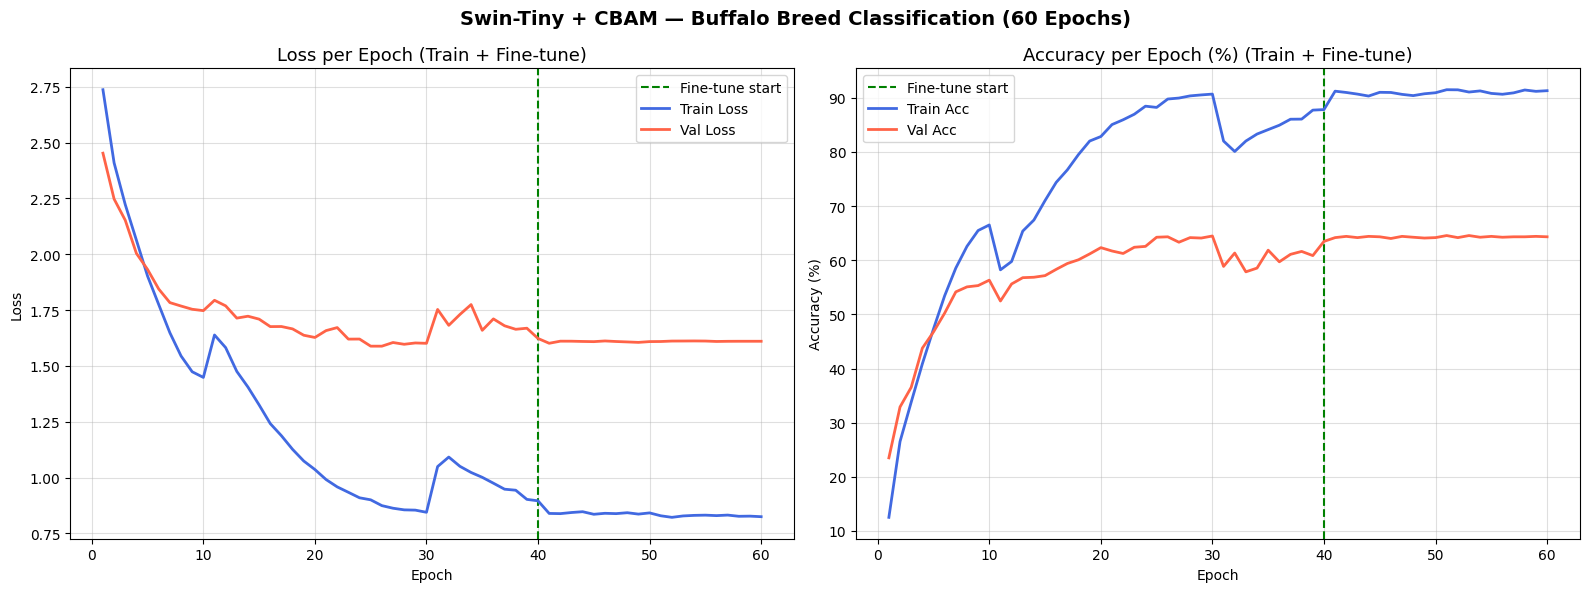

📈 Saved: /content/drive/MyDrive/sheep_folder_swintransformer/training_history.png


In [ ]:
import matplotlib.pyplot as plt

# ── 40 epochs training ──
train_loss_main = [2.7363,2.4090,2.2222,2.0629,1.9022,1.7748,1.6485,1.5447,
                   1.4739,1.4486,1.6385,1.5819,1.4754,1.4053,1.3254,1.2418,
                   1.1875,1.1265,1.0744,1.0363,0.9915,0.9586,0.9344,0.9098,
                   0.9007,0.8748,0.8631,0.8558,0.8546,0.8449,1.0496,1.0921,
                   1.0506,1.0231,1.0014,0.9751,0.9483,0.9437,0.9027,0.8962]

val_loss_main   = [2.4522,2.2472,2.1522,2.0037,1.9318,1.8443,1.7834,1.7681,
                   1.7536,1.7475,1.7938,1.7689,1.7140,1.7225,1.7094,1.6760,
                   1.6764,1.6657,1.6374,1.6274,1.6581,1.6716,1.6200,1.6203,
                   1.5885,1.5884,1.6048,1.5969,1.6028,1.6012,1.7528,1.6818,
                   1.7304,1.7746,1.6594,1.7105,1.6797,1.6640,1.6688,1.6229]

train_acc_main  = [0.1251,0.2651,0.3378,0.4086,0.4732,0.5344,0.5856,0.6257,
                   0.6549,0.6652,0.5823,0.5977,0.6538,0.6743,0.7103,0.7439,
                   0.7670,0.7954,0.8202,0.8285,0.8506,0.8595,0.8697,0.8846,
                   0.8823,0.8978,0.8996,0.9036,0.9054,0.9069,0.8202,0.8009,
                   0.8202,0.8331,0.8413,0.8494,0.8605,0.8607,0.8773,0.8783]

val_acc_main    = [0.2350,0.3290,0.3652,0.4376,0.4676,0.5023,0.5416,0.5508,
                   0.5532,0.5632,0.5247,0.5562,0.5678,0.5686,0.5716,0.5832,
                   0.5940,0.6009,0.6117,0.6233,0.6171,0.6125,0.6240,0.6256,
                   0.6425,0.6433,0.6333,0.6418,0.6410,0.6448,0.5886,0.6133,
                   0.5786,0.5855,0.6186,0.5971,0.6109,0.6163,0.6086,0.6348]

# ── 20 epochs fine-tuning ──
train_loss_ft = [0.8398,0.8389,0.8439,0.8475,0.8360,0.8404,0.8389,0.8430,
                 0.8368,0.8422,0.8293,0.8223,0.8286,0.8311,0.8321,0.8300,
                 0.8324,0.8270,0.8277,0.8252]

val_loss_ft   = [1.6014,1.6108,1.6107,1.6095,1.6087,1.6118,1.6093,1.6074,
                 1.6054,1.6089,1.6093,1.6113,1.6115,1.6118,1.6114,1.6095,
                 1.6102,1.6104,1.6104,1.6104]

train_acc_ft  = [0.9123,0.9099,0.9069,0.9033,0.9102,0.9099,0.9064,0.9041,
                 0.9075,0.9094,0.9150,0.9148,0.9107,0.9128,0.9082,0.9066,
                 0.9092,0.9145,0.9120,0.9132]

val_acc_ft    = [0.6418,0.6441,0.6418,0.6441,0.6433,0.6402,0.6441,0.6425,
                 0.6410,0.6418,0.6456,0.6418,0.6456,0.6425,0.6441,0.6425,
                 0.6433,0.6433,0.6441,0.6433]

# ── Combine both ──
all_train_loss = train_loss_main + train_loss_ft
all_val_loss   = val_loss_main   + val_loss_ft
all_train_acc  = train_acc_main  + train_acc_ft
all_val_acc    = val_acc_main    + val_acc_ft

epochs = list(range(1, len(all_train_loss) + 1))

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vertical line at epoch 40 (fine-tune start)
for ax in axes:
    ax.axvline(x=40, color='green', linestyle='--', lw=1.5, label='Fine-tune start')

axes[0].plot(epochs, all_train_loss, label="Train Loss", color="royalblue", lw=2)
axes[0].plot(epochs, all_val_loss,   label="Val Loss",   color="tomato",    lw=2)
axes[0].set_title("Loss per Epoch (Train + Fine-tune)", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(epochs, [a*100 for a in all_train_acc], label="Train Acc", color="royalblue", lw=2)
axes[1].plot(epochs, [a*100 for a in all_val_acc],   label="Val Acc",   color="tomato",    lw=2)
axes[1].set_title("Accuracy per Epoch (%) (Train + Fine-tune)", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle("Swin-Tiny + CBAM — Buffalo Breed Classification (60 Epochs)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

HIST_PATH = "/content/drive/MyDrive/sheep_folder_swintransformer/training_history.png"
plt.savefig(HIST_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"📈 Saved: {HIST_PATH}")

In [ ]:
path = '/content/drive/MyDrive/sheep_folder_swintransformer'
for f in os.listdir(path):
    print(f)

best_cow_model.pth
buffalo_datset.zip
best_buffalo_cbam.pth
training_history.png
best_buffalo_finetuned.pth
buffalo_checkpoints
BUFFALO.ipynb


In [ ]:
CHECKPOINT_PATH = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints'

import os
print(os.listdir(CHECKPOINT_PATH))

['checkpoint_latest.pth', 'best_model.pth', 'phase1_best.pth', 'phase2_best.pth', 'phase3_best.pth']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm -q

import torch, torch.nn as nn, timm, os, zipfile, shutil, random
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

ZIP_PATH        = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_datset.zip'
EXTRACT_PATH    = '/content/buffalo_dataset'
TRAIN_PATH      = '/content/buffalo_dataset/buffalo_datset'
VAL_PATH        = '/content/buffalo_dataset/val'
CHECKPOINT_PATH = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints'

# Unzip
print("\n📦 Unzipping...")
os.makedirs(EXTRACT_PATH, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)
print("✅ Unzip Done!")

# Augment
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
])

def augment_breed(breed_path, target=883):
    originals = [f for f in os.listdir(breed_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))
                 and not f.startswith('aug_')]
    needed = target - len(os.listdir(breed_path))
    if needed <= 0: return
    generated, idx = 0, 0
    while generated < needed:
        try:
            img = Image.open(os.path.join(
                breed_path, originals[idx % len(originals)]
            )).convert('RGB')
            aug_transform(img).save(
                os.path.join(breed_path, f'aug_{generated:04d}.jpg'),
                quality=90
            )
            generated += 1
        except: pass
        idx += 1

breeds = sorted(os.listdir(TRAIN_PATH))
print("\n🔄 Augmenting...")
for i, breed in enumerate(breeds):
    augment_breed(os.path.join(TRAIN_PATH, breed), target=883)
    print(f"  [{i+1}/17] {breed} ✅")
print("✅ Augmentation Done!")

# Val Split
os.makedirs(VAL_PATH, exist_ok=True)
print("\n✂️  Val Split...")
for breed in breeds:
    breed_train = os.path.join(TRAIN_PATH, breed)
    breed_val   = os.path.join(VAL_PATH, breed)
    os.makedirs(breed_val, exist_ok=True)
    all_imgs = [f for f in os.listdir(breed_train)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(all_imgs)
    for img in all_imgs[:83]:
        shutil.move(os.path.join(breed_train, img),
                    os.path.join(breed_val, img))
print("✅ Val Split Done!")

# Model Define
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        avg  = self.fc(self.avg_pool(x).view(b, c))
        max_ = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + max_).view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg     = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x,  dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

class CBAMBridge(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.cbam = CBAM(in_channels, reduction)
    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.cbam(x)
        return x.permute(0, 2, 3, 1)

class SwinCBAM(nn.Module):
    def __init__(self, num_classes=17):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=False,
            num_classes=0,
            global_pool=''
        )
        self.cbam0 = CBAMBridge(96)
        self.cbam1 = CBAMBridge(192)
        self.cbam2 = CBAMBridge(384)
        self.cbam3 = CBAMBridge(768)
        self.head  = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.use_cbam = True

    def forward(self, x):
        x = self.swin.patch_embed(x)
        if hasattr(self.swin, 'absolute_pos_embed') \
                and self.swin.absolute_pos_embed is not None:
            x += self.swin.absolute_pos_embed
        if hasattr(self.swin, 'pos_drop'):
            x = self.swin.pos_drop(x)
        for layer, cbam in zip(self.swin.layers,
                               [self.cbam0, self.cbam1,
                                self.cbam2, self.cbam3]):
            x = layer(x)
            if isinstance(x, tuple): x = x[0]
            if self.use_cbam: x = cbam(x)
        return self.head(x.mean(dim=[1, 2]))

# Load phase3_best (82.71%)
model = SwinCBAM(num_classes=17).to(device)
model.load_state_dict(
    torch.load(f'{CHECKPOINT_PATH}/phase3_best.pth',
               map_location=device)
)
print("\n✅ phase3_best Loaded! (82.71%)")

# DataLoaders
train_ds = datasets.ImageFolder(TRAIN_PATH, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
]))
val_ds = datasets.ImageFolder(VAL_PATH, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
]))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"✅ Train: {len(train_ds)} | Val: {len(val_ds)}")

# Phase 3 Retry - Higher LR!
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': model.swin.layers[0].parameters(), 'lr': 5e-6},
    {'params': model.swin.layers[1].parameters(), 'lr': 5e-6},
    {'params': model.swin.layers[2].parameters(), 'lr': 8e-6},
    {'params': model.swin.layers[3].parameters(), 'lr': 8e-6},
    {'params': model.cbam0.parameters(),          'lr': 5e-5},
    {'params': model.cbam1.parameters(),          'lr': 5e-5},
    {'params': model.cbam2.parameters(),          'lr': 5e-5},
    {'params': model.cbam3.parameters(),          'lr': 5e-5},
    {'params': model.head.parameters(),           'lr': 5e-5},
], weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-8)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("\n🚀 Phase 3 Retry! (20 epochs)")
print("   82.71% → 85%+ target!\n")

best_val = 82.71

for epoch in range(20):
    # Train
    model.train()
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"  E{epoch+1} Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        correct += out.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    train_acc = 100.*correct/total

    # Val
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"  E{epoch+1} Val  "):
            imgs, labels = imgs.to(device), labels.to(device)
            correct += model(imgs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    val_acc = 100.*correct/total
    scheduler.step()

    print(f"  [{epoch+1}/20] Train: {train_acc:.2f}% | "
          f"Val: {val_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(),
                   f'{CHECKPOINT_PATH}/phase3_retry_best.pth')
        print(f"  🏆 Best! ({best_val:.2f}%)")

print(f"\n✅ Done! Best: {best_val:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda

📦 Unzipping...
✅ Unzip Done!

🔄 Augmenting...
  [1/17] Chhattisgarhi ✅
  [2/17] Jaffarabadi ✅
  [3/17] banni ✅
  [4/17] bargur ✅
  [5/17] bhadwari ✅
  [6/17] chilika ✅
  [7/17] gojri ✅
  [8/17] kalahandi ✅
  [9/17] luit_(swamp) ✅
  [10/17] marathwadi ✅
  [11/17] mehsana ✅
  [12/17] murrah ✅


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  [13/17] nagpuri ✅
  [14/17] nili-ravi ✅
  [15/17] pandharpuri ✅
  [16/17] surti ✅
  [17/17] toda ✅
✅ Augmentation Done!

✂️  Val Split...
✅ Val Split Done!

✅ phase3_best Loaded! (82.71%)
✅ Train: 13585 | Val: 1411

🚀 Phase 3 Retry! (20 epochs)
   82.71% → 85%+ target!



  E1 Val  : 100%|██████████| 89/89 [00:13<00:00,  6.60it/s]


  [1/20] Train: 87.64% | Val: 90.86% | LR: 4.97e-06
  🏆 Best! (90.86%)


...

  [18/20] Train: 92.59% | Val: 89.58% | LR: 1.32e-07


  E19 Val  : 100%|██████████| 89/89 [00:13<00:00,  6.79it/s]


  [19/20] Train: 92.76% | Val: 89.58% | LR: 4.07e-08


  E20 Val  : 100%|██████████| 89/89 [00:12<00:00,  6.92it/s]

  [20/20] Train: 92.78% | Val: 89.58% | LR: 1.00e-08

✅ Done! Best: 90.86%


In [ ]:
# ================================
# Final Model Save
# ================================
torch.save(
    model.state_dict(),
    '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_final_90.pth'
)
print("✅ Model Saved! buffalo_final_90.pth")

✅ Model Saved! buffalo_final_90.pth


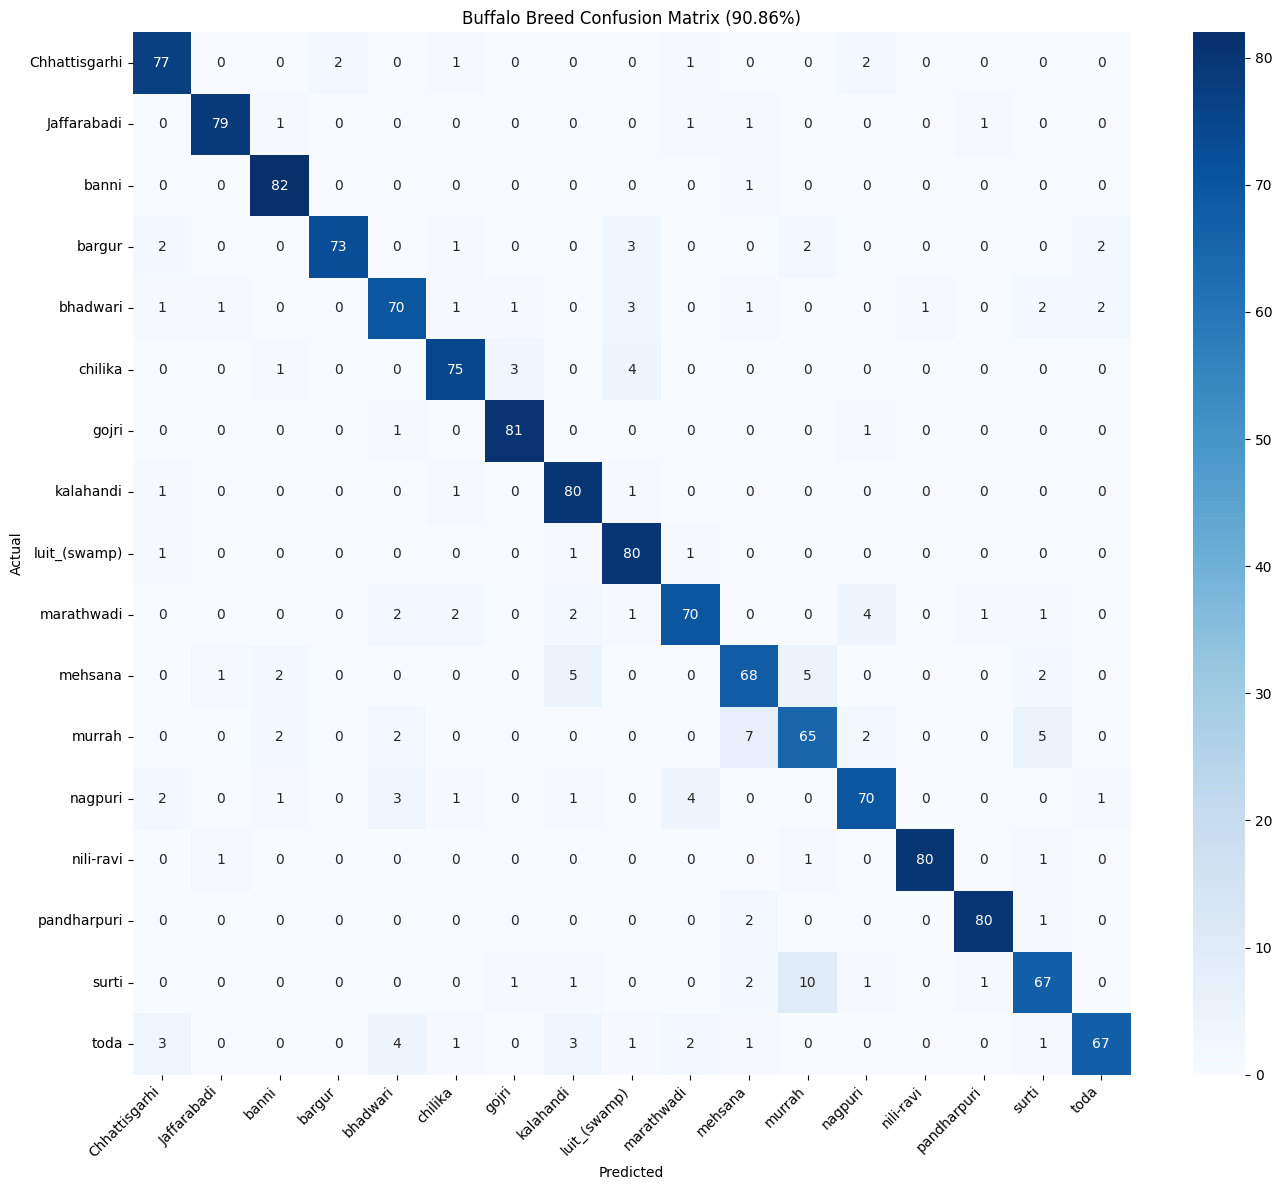

✅ Confusion Matrix Saved!


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

classes = val_ds.classes

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title('Buffalo Breed Confusion Matrix (90.86%)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/sheep_folder_swintransformer/confusion_matrix.png',
    dpi=150
)
plt.show()
print("✅ Confusion Matrix Saved!")